In [ ]:
# Project 1: Supermarket Sales Analysis (Retail Domain)

**Executive Summary**  
- Analyzed 1,000 transactions from 3 branches (Jan–Mar 2019)  
- Total Revenue: $322,966.75  
- Average Transaction: $322.97 | Median: $253.85  
- Top Categories: Food & beverages, Fashion accessories, Electronic accessories  
- Customer Insights: Females ~51%, Members vs Normal nearly equal  
- Recommendations: Promote top products, target females, convert Normal → Member customers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [2]:
# Load data directly
df = pd.read_csv('https://raw.githubusercontent.com/vnaumq/supermarket_sales/main/supermarket_sales.csv')

# Clean
df['Date'] = pd.to_datetime(df['Date'])
df = df.drop_duplicates()

print("✅ Data loaded! Rows:", df.shape[0])
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

✅ Data loaded! Rows: 1000
Date range: 2019-01-01 to 2019-03-30


In [3]:
print("\n=== Key Statistics ===")
print("Total Sales ($):", round(df['Total'].sum(), 2))
print("Average Sale ($):", round(df['Total'].mean(), 2))
print("Median Sale ($):", round(df['Total'].median(), 2))


=== Key Statistics ===
Total Sales ($): 322966.75
Average Sale ($): 322.97
Median Sale ($): 253.85


In [4]:
print("\n=== Data Quality Checks ===")
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


=== Data Quality Checks ===
Missing values:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64
Duplicates: 0


In [5]:
daily_sales = df.groupby('Date')['Total'].sum().reset_index()
product_sales = df.groupby('Product line')['Total'].sum().sort_values(ascending=False)
gender_sales = df.groupby('Gender')['Total'].sum()
customer_sales = df.groupby('Customer type')['Total'].sum()

C:\Users\boyal\AppData\Local\Temp\ipykernel_14888\1154502911.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.values, y=product_sales.index, palette='viridis', ax=axes[0,0])
C:\Users\boyal\AppData\Local\Temp\ipykernel_14888\1154502911.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_sales.index, y=customer_sales.values, palette='Set2', ax=axes[1,1])


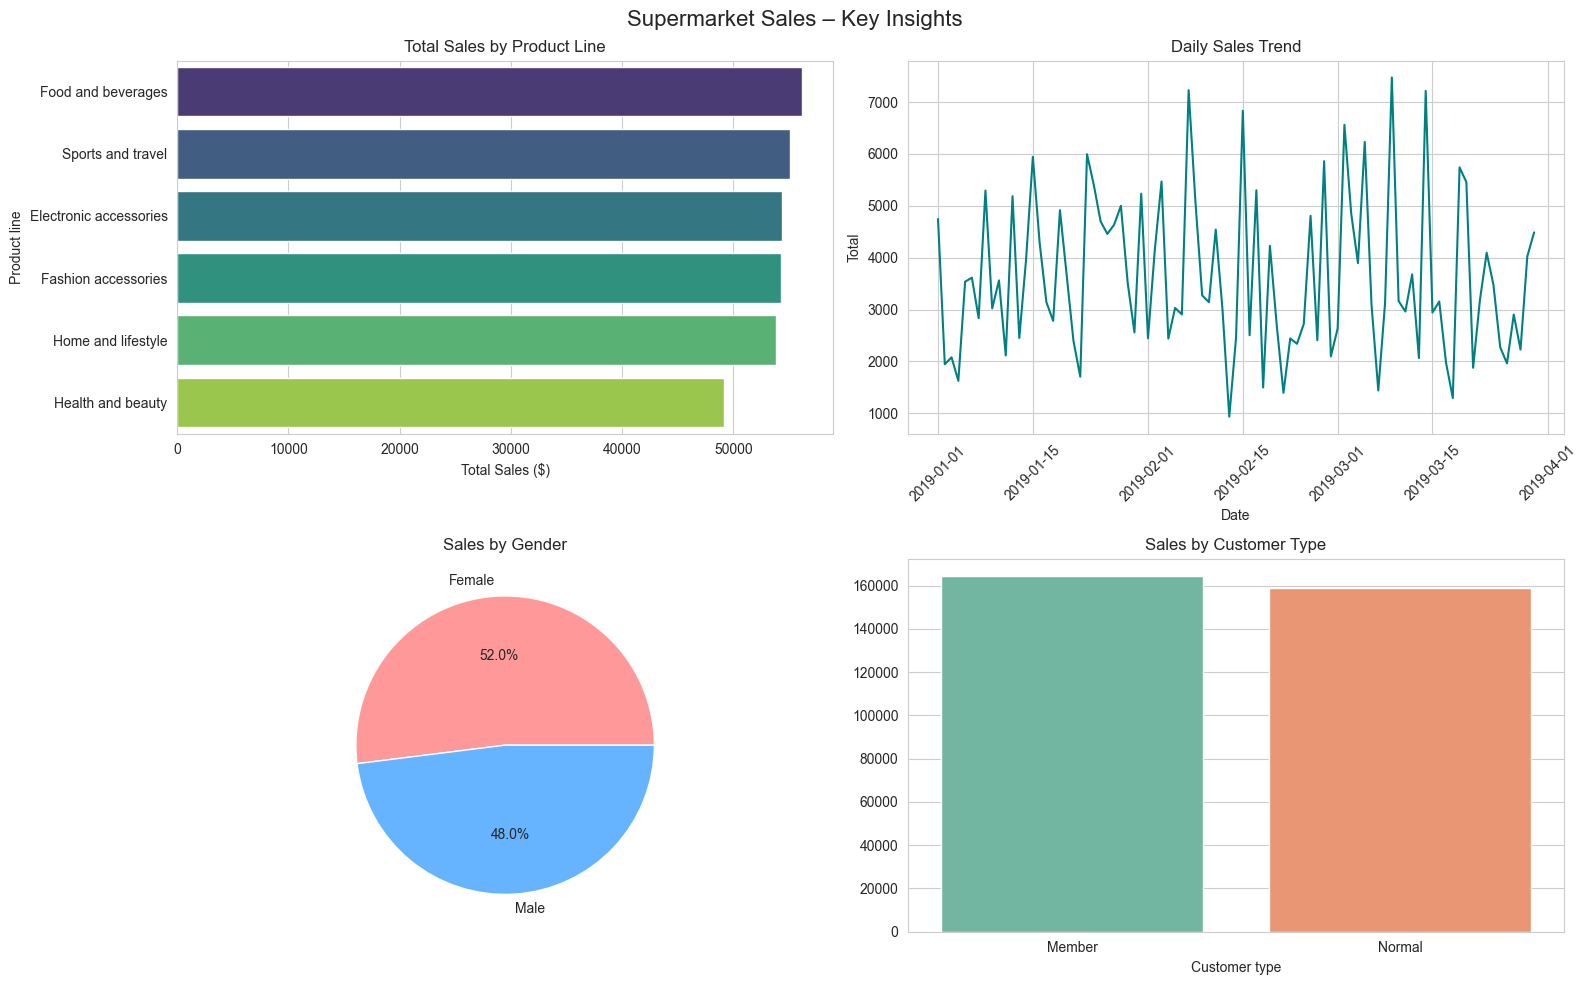

Visuals saved as 'supermarket_visuals.png'


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Supermarket Sales – Key Insights', fontsize=16)

# 1. Product Line Bar
sns.barplot(x=product_sales.values, y=product_sales.index, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Total Sales by Product Line')
axes[0,0].set_xlabel('Total Sales ($)')

# 2. Daily Trend Line
sns.lineplot(data=daily_sales, x='Date', y='Total', color='teal', ax=axes[0,1])
axes[0,1].set_title('Daily Sales Trend')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Gender Pie
gender_sales.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], ax=axes[1,0])
axes[1,0].set_title('Sales by Gender')
axes[1,0].set_ylabel('')

# 4. Customer Type Bar
sns.barplot(x=customer_sales.index, y=customer_sales.values, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Sales by Customer Type')

plt.tight_layout()
plt.show()

fig.savefig('supermarket_visuals.png', dpi=300, bbox_inches='tight')
print("Visuals saved as 'supermarket_visuals.png'")

In [7]:
print("\n=== Business Insights ===")
print("1. Top Product Line:", product_sales.idxmax(), f"(${product_sales.max():.2f})")
print("2. Best Performing City:", df.groupby('City')['Total'].sum().idxmax())
print("3. Gender Split: Female {:.1f}% | Male {:.1f}%".format(
    (gender_sales['Female']/gender_sales.sum()*100),
    (gender_sales['Male']/gender_sales.sum()*100)
))
print("4. Members vs Normal: Nearly equal revenue")

print("\n=== Actionable Recommendations ===")
print("• Promote 'Food and beverages', 'Fashion accessories', 'Electronic accessories' heavily")
print("• Target female customers with fashion/beauty/health campaigns")
print("• Launch loyalty program to convert Normal → Member customers")
print("• Offer discounts on Ewallet/Credit card payments")
print("• Analyze daily peaks for better staffing and flash sales")


=== Business Insights ===
1. Top Product Line: Food and beverages ($56144.84)
2. Best Performing City: Naypyitaw
3. Gender Split: Female 52.0% | Male 48.0%
4. Members vs Normal: Nearly equal revenue

=== Actionable Recommendations ===
• Promote 'Food and beverages', 'Fashion accessories', 'Electronic accessories' heavily
• Target female customers with fashion/beauty/health campaigns
• Launch loyalty program to convert Normal → Member customers
• Offer discounts on Ewallet/Credit card payments
• Analyze daily peaks for better staffing and flash sales
